# LeetCode #441: Arranging Coins

https://leetcode.com/problems/arranging-coins/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(\sqrt{n})$ | $O(1)$ |
| **Math (closed form)** | $O(1)$ | $O(1)$ |
| **Binary Search** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Subtract 1, 2, 3, … coins from `n` until the next row can't be filled. Steps $\approx \sqrt{2n}$.

### Math (closed form)
Solve $k(k+1)/2 \leq n$ for the largest integer $k$: $k = \lfloor (-1 + \sqrt{1 + 8n}) / 2 \rfloor$. $O(1)$ but requires floating-point square root — may have precision errors near exact squares.

### Optimal: Binary Search ★
Binary search over $k \in [1, n]$ for the largest $k$ such that $k(k+1)/2 \leq n$. Use `long` to avoid overflow. When the loop ends, `hi` is the answer. Avoids floating-point entirely.

**Why this is better than Math:** Binary search is exact — no floating-point precision risk. Simpler to verify correctness than the closed-form formula.

**Constraints:**
* 1 <= n <= 2^31 - 1

## Solutions

### C#

In [ ]:
public class Solution {
    public int ArrangeCoins(int n) {
        long lo = 1, hi = n;
        while (lo <= hi) {
            long mid = lo + (hi - lo) / 2;
            long coins = mid * (mid + 1) / 2;
            if (coins == n) return (int)mid;
            // mid rows use fewer coins than n — try fitting more rows
            if (coins < n) lo = mid + 1;
            else hi = mid - 1;
        }
        // hi is the largest k where k*(k+1)/2 <= n
        return (int)hi;
    }
}

### Python

In [ ]:
class Solution:
    def arrangeCoins(self, n: int) -> int:
        lo, hi = 1, n
        while lo <= hi:
            mid = lo + (hi - lo) // 2
            coins = mid * (mid + 1) // 2
            if coins == n:
                return mid
            # mid rows use fewer coins than n — try fitting more rows
            if coins < n:
                lo = mid + 1
            else:
                hi = mid - 1
        # hi is the largest k where k*(k+1)/2 <= n
        return hi

### Go

In [ ]:
func arrangeCoins(n int) int {
    lo, hi := 1, n
    for lo <= hi {
        mid := lo + (hi-lo)/2
        coins := mid * (mid + 1) / 2
        if coins == n {
            return mid
        }
        // mid rows use fewer coins than n — try fitting more rows
        if coins < n {
            lo = mid + 1
        } else {
            hi = mid - 1
        }
    }
    // hi is the largest k where k*(k+1)/2 <= n
    return hi
}

### Rust

In [ ]:
impl Solution {
    pub fn arrange_coins(n: i32) -> i32 {
        let (mut lo, mut hi) = (1i64, n as i64);
        while lo <= hi {
            let mid = lo + (hi - lo) / 2;
            let coins = mid * (mid + 1) / 2;
            if coins == n as i64 { return mid as i32; }
            // mid rows use fewer coins than n — try fitting more rows
            if coins < n as i64 { lo = mid + 1; } else { hi = mid - 1; }
        }
        // hi is the largest k where k*(k+1)/2 <= n
        hi as i32
    }
}

## Example Scenarios

**1. Common Case**
**Input:** n=5
lo=1, hi=5 → mid=3, coins=6>5 → hi=2. mid=1, coins=1<5 → lo=2. mid=2, coins=3<5 → lo=3. lo>hi. Return hi=2. Rows: 1+2=3 coins, row 3 incomplete.

**2. Slightly Complex**
**Input:** n=8
lo=1, hi=8 → mid=4, coins=10>8 → hi=3. mid=2, coins=3<8 → lo=3. mid=3, coins=6<8 → lo=4. lo>hi. Return hi=3. Row 4 needs 4 coins but only 2 remain.

**3. Edge Case: Time Factor**
**Input:** n = 2^31 − 1
Binary search runs $\lfloor \log_2(2^{31}-1) \rfloor = 30$ iterations. Without `long`, `mid*(mid+1)/2` overflows for `mid` near $\sqrt{2 \times 2^{31}} \approx 65535$. Answer: $k \approx 65535$ (since $65535 \times 65536 / 2 \approx 2^{31}$).

**4. Edge Case: Space Factor**
**Input:** n=1
lo=1, hi=1 → mid=1, coins=1 == 1 → return 1. Only 1 complete row. Loop runs once; $O(1)$ space. The formula $k(k+1)/2 = 1$ yields $k=1$ exactly.

**5. Almost-Impossible but Plausible**
**Input:** n = 2147418240 = 65535×65536/2 (exact triangular number)
Binary search finds mid=65535 → coins = 65535×65536/2 = 2147418240 == n → return 65535 immediately. Exact hit avoids falling through to the `hi` return. Without long, 65535×65536 = 4294901760 overflows 32-bit int.

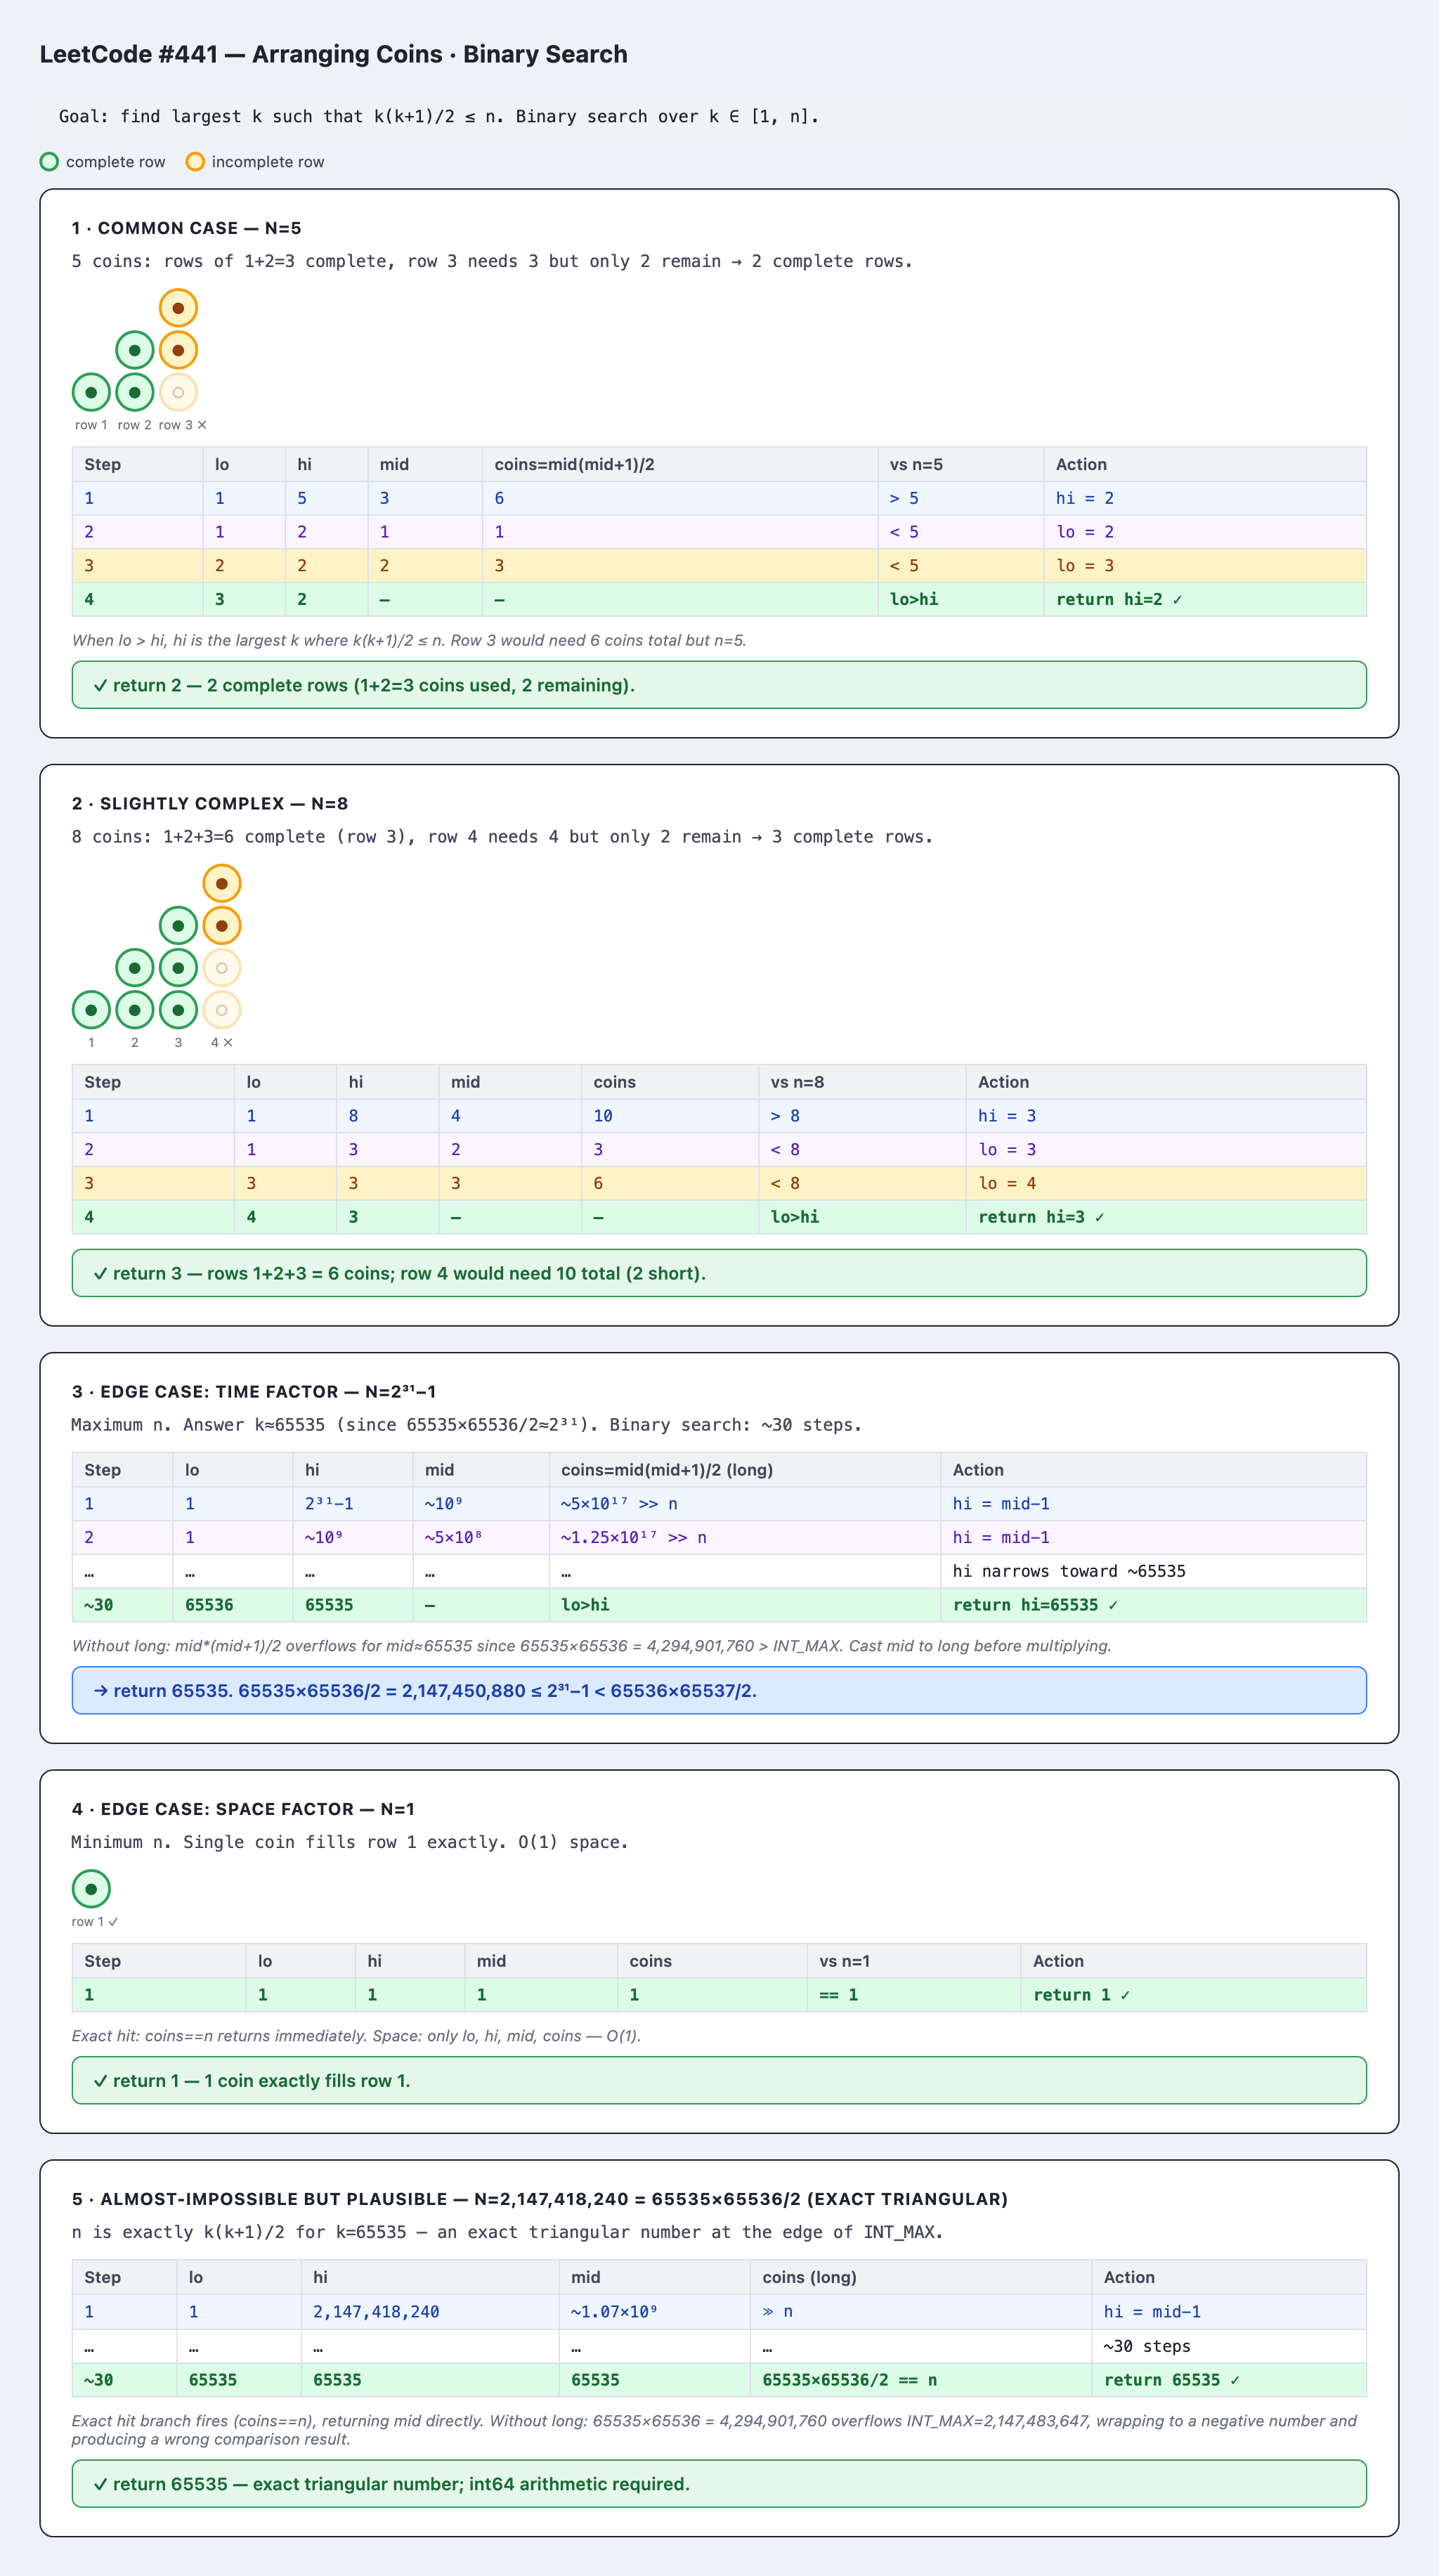